# Kill-Switch: does per-user temporal frequency conditioning actually work?

**One question.** Does conditioning the time-rotary frequency spectrum on the user
beat a single globally-learned spectrum?

Four arms, identical in every respect except where the spectrum comes from:

| arm | spectrum | role |
|---|---|---|
| `fixed` | `f_i = default_i` (frozen) | anchor |
| `global` | `f_i = default_i · exp(δ_i)`, δ a free parameter | **baseline** |
| `user` | `f_i = default_i · exp(δ_i(f_u))`, δ from a hypernetwork | **hypothesis** |
| `shuffle` | same as `user`, each user given **another user's** features | **control** |

`shuffle` is the arm that decides whether a `user > global` gap is real
personalisation or just the hypernetwork acting as extra capacity. Do not skip it.

**Deliberately disabled** (each is a separate contribution and a confound here):
content-aware phase shift, YaRN attention temperature, diversity regulariser,
Y/M/D decomposition.

## 1. Setup

In [1]:
import os, sys, math, json, time, copy, random, argparse, zipfile, urllib.request
from collections import defaultdict
from typing import NamedTuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    from scipy import stats as _scipy_stats
except ImportError:
    _scipy_stats = None

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SECONDS_PER_DAY = 86400.0
ARMS = ["fixed", "global", "user", "shuffle"]

CONFIG = {
    "maxlen": 50, "hidden_units": 64, "num_blocks": 2, "num_heads": 1,
    "dropout_rate": 0.5, "lr": 0.001, "batch_size": 512,
    "num_epochs": 200, "eval_interval": 10, "patience": 60,
    "grad_clip": 1.0, "topk": [5, 10],
    "n_feat": 9, "meta_hidden": (32, 16), "delta_scale": 0.7,
    "period_min_days": 1.0 / 24.0,      # fastest clock: 1 hour
    "period_max_days": 5 * 365.25,      # slowest clock: 5 years
}

# pre-registered decision rule -- fix this BEFORE looking at any result
DECISION = {"min_rel_gain_pct": 2.0, "alpha": 0.05}

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)

print("device:", DEVICE)

device: cuda


## 2. Data

**MovieLens-1M, not Amazon 5-core.** Amazon 5-core gives ~8.6 interactions/user,
i.e. ~5.6 inter-event gaps after leave-one-out. The 9-dim user temporal feature
vector cannot be estimated from that — the simulated coefficient of variation of
the std-gap estimator at n=6 is 0.53, so roughly half the variance in `f(u)` is
sampling noise rather than user difference. ML-1M gives ~165/user.

Caveat worth knowing: ML-1M timestamps record when someone *rated* a film, not when
they watched it, and many users rate in bursts. That is still a per-user
characteristic, so it is a valid testbed — but confirm on Steam or Yelp before
believing a positive result.

In [2]:
def download_ml1m(data_dir="data"):
    os.makedirs(data_dir, exist_ok=True)
    raw = os.path.join(data_dir, "ml-1m", "ratings.dat")
    if os.path.exists(raw):
        return raw
    zpath = os.path.join(data_dir, "ml-1m.zip")
    if not os.path.exists(zpath):
        print("downloading ML-1M ...")
        urllib.request.urlretrieve(
            "https://files.grouplens.org/datasets/movielens/ml-1m.zip", zpath)
    with zipfile.ZipFile(zpath) as z:
        z.extractall(data_dir)
    return raw


def prepare_ml1m(raw_path, out_path="data/ml1m.txt", min_user=20, min_item=5):
    # ratings.dat (u::i::r::t) -> tab-separated:  user <TAB> item <TAB> unix_ts
    rows = []
    with open(raw_path, encoding="latin-1") as f:
        for line in f:
            p = line.strip().split("::")
            if len(p) == 4:
                rows.append((p[0], p[1], int(p[3])))
    print(f"raw interactions: {len(rows):,}")

    for _ in range(10):                       # iterative core filtering
        ic = defaultdict(int)
        for _, i, _ in rows: ic[i] += 1
        rows = [r for r in rows if ic[r[1]] >= min_item]
        uc = defaultdict(int)
        for u, _, _ in rows: uc[u] += 1
        new = [r for r in rows if uc[r[0]] >= min_user]
        if len(new) == len(rows): break
        rows = new

    users = {r[0] for r in rows}
    print(f"filtered: {len(rows):,} interactions, {len(users):,} users, "
          f"{len({r[1] for r in rows}):,} items "
          f"({len(rows)/len(users):.1f}/user)")

    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)
    rows.sort(key=lambda r: (r[0], r[2]))
    with open(out_path, "w") as f:
        for u, i, ts in rows:
            f.write(f"{u}\t{i}\t{ts}\n")
    return out_path

### 2.1 Loading, user features, leave-one-out split

In [3]:
class SequentialDataset(NamedTuple):
    user_seqs: dict
    user_times: dict
    user_features: dict
    num_users: int
    num_items: int


def compute_user_temporal_features(user_times, recent_k=10, clip_sigma=3.0):
    # 9-dim per-user temporal profile. MUST be fed train-only timestamps.
    feats = {}
    all_last = [t[-1] for t in user_times.values() if t]
    max_time = max(all_last) if all_last else 1.0

    for uid, times in user_times.items():
        n = len(times)
        if n < 2:
            f = np.zeros(9, dtype=np.float32); f[5] = np.log1p(n)
            feats[uid] = f; continue
        span = max(times[-1] - times[0], 1.0)
        gaps = np.diff(times).astype(np.float64) / 3600.0          # hours
        k = min(recent_k, n)
        r = times[-k:]
        r_span = max(r[-1] - r[0], 1.0)
        feats[uid] = np.array([
            np.log1p(n / (span / 3600.0)),        # global density
            np.log1p(k / (r_span / 3600.0)),      # recent density
            np.log1p(np.mean(gaps)),              # mean gap
            np.log1p(np.std(gaps)),               # std gap
            np.log1p(np.max(gaps)),               # max gap
            np.log1p(n),                          # sequence length
            times[-1] / max_time,                 # recency
            np.sin(2*np.pi*((times[-1] % 86400)/3600.0)/24.0),
            np.cos(2*np.pi*((times[-1] % 86400)/3600.0)/24.0),
        ], dtype=np.float32)

    M = np.stack([feats[u] for u in feats])
    # clip outliers BEFORE standardising: a handful of extreme users can
    # otherwise dominate the hypernetwork's input distribution
    med = np.median(M, axis=0, keepdims=True)
    mad = np.median(np.abs(M - med), axis=0, keepdims=True) * 1.4826 + 1e-8
    M = np.clip(M, med - clip_sigma * mad, med + clip_sigma * mad)
    mean, std = M.mean(0, keepdims=True), M.std(0, keepdims=True) + 1e-8
    M = (M - mean) / std
    for j, u in enumerate(feats):
        feats[u] = M[j].astype(np.float32)
    return feats


def load_data(filepath):
    raw = defaultdict(list)
    with open(filepath) as f:
        for line in f:
            p = line.strip().split("\t")
            if len(p) >= 3:
                raw[p[0]].append((p[1], float(p[2])))
    for u in raw:
        raw[u].sort(key=lambda x: x[1])

    user2idx, item2idx, seqs, times_d = {}, {}, {}, {}
    for ru, inter in raw.items():
        user2idx.setdefault(ru, len(user2idx) + 1)
        uid = user2idx[ru]
        first = inter[0][1]
        items, ts = [], []
        for ri, t in inter:
            item2idx.setdefault(ri, len(item2idx) + 1)
            items.append(item2idx[ri]); ts.append(t - first)   # user-relative
        seqs[uid], times_d[uid] = items, ts

    # features from TRAIN timestamps only (exclude val + test items)
    train_times = {u: (t[:-2] if len(t) >= 3 else t) for u, t in times_d.items()}
    return SequentialDataset(seqs, times_d,
                             compute_user_temporal_features(train_times),
                             len(user2idx), len(item2idx))

### 2.2 Sampler

In [4]:
class TrainSampler:
    def __init__(self, ds, maxlen=50, batch_size=512):
        self.ds, self.maxlen, self.bs = ds, maxlen, batch_size
        self.user_sets = {u: set(v) for u, v in ds.user_seqs.items()}
        self.users = [u for u, v in ds.user_seqs.items() if len(v) >= 3]

    def _pad(self, s, val=0):
        return ([val] * max(0, self.maxlen - len(s)) + list(s))[-self.maxlen:]

    def _neg(self, uid):
        s = self.user_sets[uid]
        while True:
            n = random.randint(1, self.ds.num_items)
            if n not in s:
                return n

    def train_epoch(self):
        random.shuffle(self.users)
        for i in range(0, len(self.users), self.bs):
            batch = self.users[i:i + self.bs]
            logs, tms, poss, negs, fts = [], [], [], [], []
            for uid in batch:
                it, tt = self.ds.user_seqs[uid][:-2], self.ds.user_times[uid][:-2]
                logs.append(self._pad(it[:-1]))
                tms.append(self._pad(tt[:-1], 0.0))
                pos = self._pad(it[1:]); poss.append(pos)
                negs.append([0 if p == 0 else self._neg(uid) for p in pos])
                fts.append(self.ds.user_features[uid])
            yield (torch.tensor(logs, dtype=torch.long),
                   torch.tensor(tms, dtype=torch.float32),
                   torch.tensor(poss, dtype=torch.long),
                   torch.tensor(negs, dtype=torch.long),
                   torch.tensor(np.stack(fts), dtype=torch.float32))

    def eval_batches(self, mode="test"):
        for i in range(0, len(self.users), self.bs):
            batch = self.users[i:i + self.bs]
            logs, tms, fts, tgts, lens = [], [], [], [], []
            for uid in batch:
                it, tt = self.ds.user_seqs[uid], self.ds.user_times[uid]
                if mode == "val":
                    inp_i, inp_t, tgt = it[:-2], tt[:-2], it[-2]
                else:
                    inp_i, inp_t, tgt = it[:-1], tt[:-1], it[-1]
                logs.append(self._pad(inp_i)); tms.append(self._pad(inp_t, 0.0))
                fts.append(self.ds.user_features[uid])
                tgts.append((tgt, set(inp_i)))
                lens.append(len(it))
            yield (torch.tensor(logs, dtype=torch.long),
                   torch.tensor(tms, dtype=torch.float32),
                   torch.tensor(np.stack(fts), dtype=torch.float32),
                   tgts, lens)

## 3. The spectrum — the only thing that differs between arms

`freq_i(u) = default_i · exp(δ_i)`, with `default` log-uniform over real temporal
periods. At initialisation every arm produces **numerically identical** output
(δ = 0), so any measured difference is attributable to conditioning rather than a
different starting point. This is asserted below.

In [5]:
def default_log_freqs(n, period_min_days, period_max_days):
    return torch.linspace(math.log(2*math.pi/period_min_days),
                          math.log(2*math.pi/period_max_days), n)


class Spectrum(nn.Module):
    def __init__(self, arm, n_freq, cfg):
        super().__init__()
        assert arm in ARMS
        self.arm = arm
        self.register_buffer("log_freq", default_log_freqs(
            n_freq, cfg["period_min_days"], cfg["period_max_days"]))

        if arm == "global":
            self.delta = nn.Parameter(torch.zeros(n_freq))
        elif arm in ("user", "shuffle"):
            self.delta_scale = cfg["delta_scale"]
            h1, h2 = cfg["meta_hidden"]
            self.meta_mlp = nn.Sequential(
                nn.Linear(cfg["n_feat"], h1), nn.GELU(),
                nn.Linear(h1, h2), nn.GELU(),
                nn.Linear(h2, n_freq))
            for m in self.meta_mlp:
                if isinstance(m, nn.Linear):
                    nn.init.xavier_uniform_(m.weight, gain=0.1)
                    nn.init.zeros_(m.bias)
            nn.init.zeros_(self.meta_mlp[-1].weight)   # delta == 0 at init
            nn.init.zeros_(self.meta_mlp[-1].bias)

    def forward(self, uf):                       # (B,F) -> (B,n_freq)
        B = uf.shape[0]
        if self.arm == "fixed":
            return self.log_freq.exp().unsqueeze(0).expand(B, -1)
        if self.arm == "global":
            return (self.log_freq + self.delta).exp().unsqueeze(0).expand(B, -1)
        d = self.delta_scale * torch.tanh(self.meta_mlp(uf))
        return (self.log_freq.unsqueeze(0) + d).exp()


# sanity: spectrum spans a real range and the slowest clock does not wrap
_lf = default_log_freqs(32, CONFIG["period_min_days"], CONFIG["period_max_days"])
_f = _lf.exp()
print(f"fastest period {2*math.pi/_f[0]*24:.2f} h   "
      f"slowest period {2*math.pi/_f[-1]/365.25:.2f} yr")
print(f"over a 3-year history the slowest dim wraps "
      f"{(3*365.25*_f[-1]/(2*math.pi)).item():.3f} times  (must be < 1)")

fastest period 1.00 h   slowest period 5.00 yr
over a 3-year history the slowest dim wraps 0.600 times  (must be < 1)


## 4. Model

Both fixes live here:

- **Timeline masking** — `x *= pad_mask` after the embedding and after every block.
- **Padding masked in attention** — padded key positions get `-inf`. The diagonal is
  always left open so that padded query rows cannot produce an all-masked softmax
  (which would be NaN).

In [6]:
class PointWiseFFN(nn.Module):
    def __init__(self, d, dr):
        super().__init__()
        self.c1, self.c2 = nn.Conv1d(d, d, 1), nn.Conv1d(d, d, 1)
        self.d1, self.d2 = nn.Dropout(dr), nn.Dropout(dr)

    def forward(self, x):
        y = self.d2(self.c2(F.relu(self.d1(self.c1(x.transpose(-1, -2))))))
        return y.transpose(-1, -2)


def build_attn_mask(seqs):
    # True == masked. causal | padded-key, with the diagonal always left open.
    B, S = seqs.shape
    dev = seqs.device
    causal = torch.triu(torch.ones(S, S, dtype=torch.bool, device=dev), 1)
    pad_key = (seqs == 0).unsqueeze(1).expand(B, S, S)          # (B,S,S)
    mask = causal.unsqueeze(0) | pad_key
    eye = torch.eye(S, dtype=torch.bool, device=dev).unsqueeze(0)
    return (mask & ~eye).unsqueeze(1)                            # (B,1,S,S)


def apply_rotary(x, cos, sin):
    xe, xo = x[..., 0::2], x[..., 1::2]
    return torch.stack((xe*cos - xo*sin, xe*sin + xo*cos), -1).flatten(-2)


class KSAttention(nn.Module):
    def __init__(self, d, heads, dr):
        super().__init__()
        self.d, self.h, self.hd = d, heads, d // heads
        self.qkv = nn.ModuleList([nn.Linear(d, d) for _ in range(3)])
        self.out = nn.Linear(d, d)
        self.drop = nn.Dropout(dr)
        # no phase_proj, no attention-temperature correction

    def forward(self, x, t_days, freq, attn_mask):
        B, S, _ = x.shape
        q, k, v = [p(x).reshape(B, S, self.h, self.hd).permute(0, 2, 1, 3)
                   for p in self.qkv]
        ang = (t_days.unsqueeze(-1) * freq.unsqueeze(1)).unsqueeze(1)
        cos, sin = ang.cos(), ang.sin()
        q, k = apply_rotary(q, cos, sin), apply_rotary(k, cos, sin)
        sc = (q @ k.transpose(-2, -1)) / math.sqrt(self.hd)
        sc = sc.masked_fill(attn_mask, float("-inf"))
        o = self.drop(F.softmax(sc, -1)) @ v
        return self.out(o.permute(0, 2, 1, 3).reshape(B, S, self.d))


class SASRecKillSwitch(nn.Module):
    def __init__(self, item_num, arm, cfg):
        super().__init__()
        d, heads, blocks = cfg["hidden_units"], cfg["num_heads"], cfg["num_blocks"]
        dr = cfg["dropout_rate"]
        self.d, self.arm = d, arm
        self.item_emb = nn.Embedding(item_num + 1, d, padding_idx=0)
        self.emb_drop = nn.Dropout(dr)
        self.spectrum = Spectrum(arm, (d // heads) // 2, cfg)
        self.attn_ln = nn.ModuleList([nn.LayerNorm(d, eps=1e-8) for _ in range(blocks)])
        self.attn = nn.ModuleList([KSAttention(d, heads, dr) for _ in range(blocks)])
        self.ffn_ln = nn.ModuleList([nn.LayerNorm(d, eps=1e-8) for _ in range(blocks)])
        self.ffn = nn.ModuleList([PointWiseFFN(d, dr) for _ in range(blocks)])
        self.last_ln = nn.LayerNorm(d, eps=1e-8)

    def encode(self, seqs, time_seqs, uf):
        pad = (seqs != 0).unsqueeze(-1).float()          # FIX 1: timeline mask
        x = self.emb_drop(self.item_emb(seqs) * math.sqrt(self.d)) * pad
        t_days = time_seqs.float() / SECONDS_PER_DAY
        freq = self.spectrum(uf)
        m = build_attn_mask(seqs)                        # FIX 2: pad-aware mask
        for i in range(len(self.attn)):
            x = x + self.attn[i](self.attn_ln[i](x), t_days, freq, m)
            x = x + self.ffn[i](self.ffn_ln[i](x))
            x = x * pad
        return self.last_ln(x)

    def forward(self, log, tm, pos, neg, uf):
        h = self.encode(log, tm, uf)
        return (h * self.item_emb(pos)).sum(-1), (h * self.item_emb(neg)).sum(-1)

    def predict(self, log, tm, uf):
        return self.encode(log, tm, uf)[:, -1, :] @ self.item_emb.weight.T


def init_model(m, seed=None):
    # Re-seed HERE, after construction: building the `user`/`shuffle` meta-MLP
    # consumes RNG draws, so without this every arm would get different weights
    # and the "paired" seed comparison would be confounded.
    if seed is not None:
        set_seed(seed)

    # Init per MODULE TYPE, not per parameter. A `for p in parameters():
    # try: xavier_normal_(p) except: pass` loop silently leaves every bias at
    # its constructor value -- which is RNG-stream dependent, and therefore
    # differs across arms. That is a real confound, not a cosmetic one.
    for name, mod in m.named_modules():
        if "spectrum" in name:            # its init is load-bearing; leave alone
            continue
        if isinstance(mod, (nn.Linear, nn.Conv1d)):
            nn.init.xavier_normal_(mod.weight.data)
            if mod.bias is not None:
                nn.init.zeros_(mod.bias.data)
        elif isinstance(mod, nn.LayerNorm):
            nn.init.ones_(mod.weight.data); nn.init.zeros_(mod.bias.data)
        elif isinstance(mod, nn.Embedding):
            nn.init.xavier_normal_(mod.weight.data)
    m.item_emb.weight.data[0, :] = 0
    return m

### 4.1 Assert the arms are identical at initialisation

In [7]:
_B, _S, _F = 4, CONFIG["maxlen"], CONFIG["n_feat"]
_seq = torch.randint(1, 50, (_B, _S)); _seq[:, :10] = 0        # left padding
_tm  = torch.cumsum(torch.rand(_B, _S) * 5 * SECONDS_PER_DAY, 1)
_uf  = torch.randn(_B, _F)

outs = {}
for a in ARMS:
    set_seed(0)
    mdl = init_model(SASRecKillSwitch(100, a, CONFIG), seed=0)
    mdl.eval()
    with torch.no_grad():
        outs[a] = mdl.encode(_seq, _tm, _uf)

for a in ARMS[1:]:
    diff = (outs[a] - outs["fixed"]).abs().max().item()
    print(f"  {a:<8} vs fixed at init: max abs diff = {diff:.2e}")
    assert diff < 1e-5, f"{a} differs from fixed at init -- arms are not comparable"

pad_out = outs["fixed"][:, :10, :].abs().max().item()
print(f"  padded-position activations (pre-final-LN path): {pad_out:.2e}")
print("  OK: all four arms are numerically identical at initialisation.")

  global   vs fixed at init: max abs diff = 0.00e+00
  user     vs fixed at init: max abs diff = 0.00e+00
  shuffle  vs fixed at init: max abs diff = 0.00e+00
  padded-position activations (pre-final-LN path): 0.00e+00
  OK: all four arms are numerically identical at initialisation.


## 5. Evaluation — full-catalog ranking, stratified by history length

In [8]:
def evaluate(model, sampler, mode="test", topk=(5, 10)):
    model.eval()
    ranks, lengths = [], []
    with torch.no_grad():
        for log, tm, uf, tgts, lens in sampler.eval_batches(mode):
            log, tm, uf = log.to(DEVICE), tm.to(DEVICE), uf.to(DEVICE)
            scores = model.predict(log, tm, uf)
            for i, (tgt, hist) in enumerate(tgts):
                scores[i, 0] = float("-inf")
                mask_items = list(hist - {tgt})
                if mask_items:
                    scores[i, mask_items] = float("-inf")
                ts = scores[i, tgt].item()
                ranks.append(int((scores[i, 1:] > ts).sum().item()) + 1)
            lengths.extend(lens)

    ranks, lengths = np.array(ranks), np.array(lengths)
    q1, q2 = np.percentile(lengths, [33, 67])
    groups = {"": np.ones_like(lengths, bool),
              "Short_": lengths <= q1,
              "Mid_":  (lengths > q1) & (lengths <= q2),
              "Long_":  lengths > q2}
    out = {}
    for pre, sel in groups.items():
        r = ranks[sel]
        if len(r) == 0:
            continue
        for k in topk:
            out[f"{pre}R@{k}"] = float(np.mean(r <= k))
            out[f"{pre}N@{k}"] = float(np.mean(np.where(r <= k, 1/np.log2(r+1), 0.0)))
    return out

## 6. Training loop

In [9]:
def run_one(arm, seed, dataset, cfg, verbose=False):
    set_seed(seed)
    ds = dataset

    if arm == "shuffle":
        # fixed derangement: every user gets SOMEONE ELSE'S temporal profile,
        # consistently for the whole run
        uids = sorted(ds.user_features)
        rng = np.random.default_rng(10_000 + seed)
        perm = rng.permutation(len(uids))
        for i in range(len(uids)):
            if perm[i] == i:
                j = (i + 1) % len(uids)
                perm[i], perm[j] = perm[j], perm[i]
        ds = ds._replace(user_features={uids[i]: ds.user_features[uids[perm[i]]]
                                        for i in range(len(uids))})

    sampler = TrainSampler(ds, cfg["maxlen"], cfg["batch_size"])
    model = init_model(SASRecKillSwitch(ds.num_items, arm, cfg), seed=seed).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"], betas=(0.9, 0.98))
    bce = nn.BCEWithLogitsLoss()

    best, best_state, bad, t0 = -1.0, None, 0, time.time()
    for ep in range(1, cfg["num_epochs"] + 1):
        model.train()
        for log, tm, pos, neg, uf in sampler.train_epoch():
            log, tm, pos, neg, uf = [t.to(DEVICE) for t in (log, tm, pos, neg, uf)]
            pl, nl = model(log, tm, pos, neg, uf)
            idx = torch.where(pos != 0)
            loss = (bce(pl[idx], torch.ones_like(pl[idx])) +
                    bce(nl[idx], torch.zeros_like(nl[idx])))
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            opt.step()

        if ep % cfg["eval_interval"] == 0 or ep == cfg["num_epochs"]:
            v = evaluate(model, sampler, "val", cfg["topk"])["N@10"]
            if v > best:
                best, best_state, bad = v, copy.deepcopy(model.state_dict()), 0
            else:
                bad += cfg["eval_interval"]
            if verbose:
                print(f"    ep{ep:4d}  loss {loss.item():.4f}  val N@10 {v:.4f}"
                      f"  best {best:.4f}")
            if bad >= cfg["patience"]:
                break

    model.load_state_dict(best_state)
    res = evaluate(model, sampler, "test", cfg["topk"])
    res["_val_N@10"], res["_minutes"] = best, (time.time() - t0) / 60

    with torch.no_grad():
        uf = torch.tensor(np.stack([ds.user_features[u] for u in sampler.users]),
                          dtype=torch.float32).to(DEVICE)
        spec = model.spectrum(uf).cpu().numpy()
    res["_spec_mean"] = spec.mean(0).tolist()
    res["_spec_spread"] = float(spec.std(0).mean())
    return res

## 7. Statistics and the pre-registered decision rule

In [10]:
def paired_t(a, b):
    d = np.asarray(a, float) - np.asarray(b, float)
    n = len(d)
    if n < 2:
        return float(d.mean()), float("nan"), float("nan")
    sd = d.std(ddof=1)
    if sd == 0.0 or sd < 1e-9 * max(abs(d.mean()), 1e-12):
        return float(d.mean()), float("nan"), float("nan")   # degenerate
    t = d.mean() / (sd / math.sqrt(n))
    p = (float(2 * _scipy_stats.t.sf(abs(t), df=n-1)) if _scipy_stats
         else 2*(1 - 0.5*(1 + math.erf(abs(t)/math.sqrt(2)))))
    return float(d.mean()), float(t), float(p)


def report(results, metric="N@10"):
    print(f"\n{'='*76}\n  {metric}  (mean +/- std over seeds)\n{'='*76}")
    print(f"  {'arm':<9}{'overall':<20}{'short':<18}{'mid':<18}{'long':<18}")
    for a in ARMS:
        if not results.get(a): continue
        def ms(k):
            v = [r[k] for r in results[a] if k in r]
            return f"{np.mean(v):.4f}+/-{np.std(v):.4f}" if v else "-"
        print(f"  {a:<9}{ms(metric):<20}{ms('Short_'+metric):<18}"
              f"{ms('Mid_'+metric):<18}{ms('Long_'+metric):<18}")

    if not all(results.get(a) for a in ("global", "user", "shuffle")):
        return
    g = [r[metric] for r in results["global"]]
    u = [r[metric] for r in results["user"]]
    s = [r[metric] for r in results["shuffle"]]

    print(f"\n{'-'*76}\n  DECISION  (pre-registered: >= "
          f"{DECISION['min_rel_gain_pct']}% relative AND p < {DECISION['alpha']})"
          f"\n{'-'*76}")
    for nm, x, y in [("user    vs global ", u, g),
                     ("user    vs shuffle", u, s),
                     ("shuffle vs global ", s, g)]:
        d, t, p = paired_t(x, y)
        print(f"  {nm}: {d:+.5f} ({100*d/max(np.mean(y),1e-9):+.2f}%)"
              f"  t={t:+.2f}  p={p:.4f}")

    d_ug, _, p_ug = paired_t(u, g)
    d_us, _, p_us = paired_t(u, s)
    rel = 100 * d_ug / max(np.mean(g), 1e-9)
    print()
    if rel < DECISION["min_rel_gain_pct"] or not (p_ug < DECISION["alpha"]):
        print("  >> NO EFFECT.  user-conditioning does not beat a global spectrum.")
        print("     STOP. Write the negative result; do not build the ladder.")
    elif d_us <= 0 or not (p_us < DECISION["alpha"]):
        print("  >> CAPACITY ARTIFACT.  user > global, but not > shuffle.")
        print("     The gain is hypernetwork capacity, not personalisation.")
        print("     STOP -- but this is still a reportable finding.")
    else:
        print("  >> REAL EFFECT.  user > global AND user > shuffle.")
        print("     Proceed to the capacity ladder (0 -> 2 -> 6 -> 32) and more data.")

    print("\n  across-user spectrum spread: " + "  ".join(
        f"{a}={np.mean([r['_spec_spread'] for r in results[a]]):.4f}"
        for a in ARMS if results.get(a)))
    print("    fixed/global must be 0.0000. If `user` is also ~0 the hypernetwork")
    print("    collapsed to a constant and a null result is UNINFORMATIVE --")
    print("    raise delta_scale or the meta-MLP init gain and rerun.")

## 8. Run

Set `SMOKE = True` first (a few minutes) to confirm everything runs, then
`SMOKE = False` for the real thing (~2 h on one GPU).

In [11]:
SMOKE = False          # <-- flip to False for the real run

DATA = prepare_ml1m(download_ml1m())
cfg = dict(CONFIG)
if SMOKE:
    cfg["num_epochs"], N_SEEDS = 20, 1
else:
    N_SEEDS = 5

dataset = load_data(DATA)
n_int = sum(len(v) for v in dataset.user_seqs.values())
print(f"{dataset.num_users:,} users  {dataset.num_items:,} items  "
      f"{n_int:,} interactions  ({n_int/dataset.num_users:.1f}/user)")
if n_int / dataset.num_users < 20:
    print("WARNING: <20 interactions/user -- per-user temporal features are mostly "
          "sampling noise.\n         A null result here will NOT be interpretable.")

results = {a: [] for a in ARMS}
for seed in range(N_SEEDS):
    for arm in ARMS:
        r = run_one(arm, seed, dataset, cfg, verbose=SMOKE)
        results[arm].append(r)
        print(f"  seed {seed} | {arm:<8} | test N@10 {r['N@10']:.4f} "
              f"R@10 {r['R@10']:.4f} | {r['_minutes']:.1f} min")

with open("killswitch_results.json", "w") as f:
    json.dump(results, f, indent=2)

raw interactions: 1,000,209
filtered: 999,513 interactions, 6,035 users, 3,415 items (165.6/user)
6,035 users  3,415 items  999,513 interactions  (165.6/user)
  seed 0 | fixed    | test N@10 0.1082 R@10 0.2061 | 2.5 min
  seed 0 | global   | test N@10 0.1033 R@10 0.1954 | 2.5 min
  seed 0 | user     | test N@10 0.1050 R@10 0.1985 | 2.5 min
  seed 0 | shuffle  | test N@10 0.1069 R@10 0.1993 | 2.5 min
  seed 1 | fixed    | test N@10 0.1086 R@10 0.2068 | 2.5 min
  seed 1 | global   | test N@10 0.1045 R@10 0.1962 | 2.5 min
  seed 1 | user     | test N@10 0.1042 R@10 0.1977 | 2.5 min
  seed 1 | shuffle  | test N@10 0.1064 R@10 0.2012 | 2.5 min
  seed 2 | fixed    | test N@10 0.1052 R@10 0.2027 | 2.5 min
  seed 2 | global   | test N@10 0.1056 R@10 0.2023 | 2.5 min
  seed 2 | user     | test N@10 0.1052 R@10 0.1990 | 2.6 min
  seed 2 | shuffle  | test N@10 0.1040 R@10 0.1985 | 2.6 min
  seed 3 | fixed    | test N@10 0.1097 R@10 0.2080 | 2.5 min
  seed 3 | global   | test N@10 0.1081 R@10 0.20

## 9. Results

In [12]:
report(results, "N@10")
report(results, "R@10")


  N@10  (mean +/- std over seeds)
  arm      overall             short             mid               long              
  fixed    0.1083+/-0.0017     0.1331+/-0.0025   0.1091+/-0.0027   0.0826+/-0.0011   
  global   0.1059+/-0.0019     0.1273+/-0.0021   0.1083+/-0.0033   0.0818+/-0.0013   
  user     0.1059+/-0.0014     0.1270+/-0.0028   0.1076+/-0.0020   0.0829+/-0.0023   
  shuffle  0.1062+/-0.0011     0.1272+/-0.0030   0.1088+/-0.0021   0.0825+/-0.0020   

----------------------------------------------------------------------------
  DECISION  (pre-registered: >= 2.0% relative AND p < 0.05)
----------------------------------------------------------------------------
  user    vs global : +0.00004 (+0.04%)  t=+0.09  p=0.9334
  user    vs shuffle: -0.00030 (-0.29%)  t=-0.42  p=0.6963
  shuffle vs global : +0.00034 (+0.32%)  t=+0.33  p=0.7559

  >> NO EFFECT.  user-conditioning does not beat a global spectrum.
     STOP. Write the negative result; do not build the ladder.

  across-u

## 10. What the learned spectra look like

Only meaningful if the decision above came out **REAL EFFECT**. If it did, this is
the figure for the paper: identifiable per-user frequency spectra, unlike the
(α, w) parameterisation of ChronoRoPE where many settings give the same model.

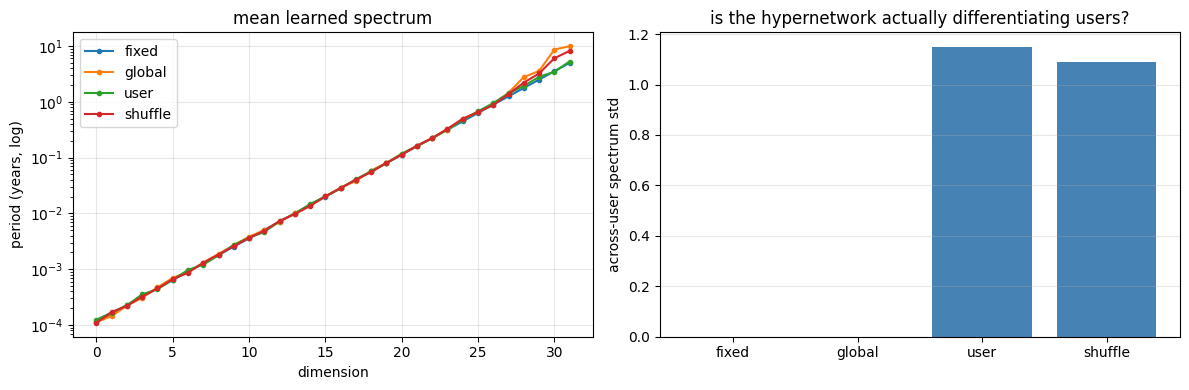

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a in ARMS:
    if results.get(a):
        f = np.array(results[a][0]["_spec_mean"])
        ax[0].plot(2*np.pi/f/365.25, marker="o", ms=3, label=a)
ax[0].set_yscale("log"); ax[0].set_xlabel("dimension")
ax[0].set_ylabel("period (years, log)"); ax[0].set_title("mean learned spectrum")
ax[0].legend(); ax[0].grid(alpha=.3)

sp = [np.mean([r["_spec_spread"] for r in results[a]]) for a in ARMS if results.get(a)]
ax[1].bar([a for a in ARMS if results.get(a)], sp, color="steelblue")
ax[1].set_ylabel("across-user spectrum std")
ax[1].set_title("is the hypernetwork actually differentiating users?")
ax[1].grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()